In [1]:
# Preparing the dataset
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
# Loading the dataset
dfFake = pd.read_csv("fake.csv")
dfTrue = pd.read_csv("true.csv")
dfFake['label'] = 1 #Fake news
dfTrue['label'] = 0 # Real news

In [3]:
# Combinig both the datasets into one and downsampling (reducing the number of rows)
df = pd.concat([dfFake, dfTrue], axis = 0).reset_index(drop = True)
df = df.sample(n=4000, random_state=42).reset_index(drop = True) # reseting the index column
df['text_data'] = df['title'] + " " + df['text']

In [5]:
# Splitting the data
X_train_raw, X_test_raw, y_train, y_test = train_test_split( df['text_data'], df['label'], test_size = 0.2, random_state = 42, stratify = df['label'])
y_train, y_test = np.array(y_train), np.array(y_test)

In [6]:
## Training Deep Learning Models 
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, LSTM, GRU, Conv1D, GlobalMaxPooling1D, Dropout, Flatten

In [7]:
MAX_VOCAB = 10000 # Selects the top 10000 most frequent words to be remembered and converted to integers by the tokenizer
MAX_LEN = 300 # The number of tekens (words or subwords) allowed in a single input sequence or sentence
# MAX_VOCAB and MAX_LEN are hyperparameters used to restrict data size

In [9]:
# Tokkenizing and padding for Deep Learning
dl_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token = "<OOV>") # OOV = Out of Vocabulary
dl_tokenizer.fit_on_texts(X_train_raw)
X_train_dl = pad_sequences(dl_tokenizer.texts_to_sequences(X_train_raw), maxlen = MAX_LEN, padding = 'post', truncating = 'post')
X_test_dl = pad_sequences(dl_tokenizer.texts_to_sequences(X_test_raw), maxlen = MAX_LEN, padding = 'post', truncating = 'post')

In [16]:
def build_and_train_dl(model_type):
    model = Sequential()
    model.add(Embedding(input_dim = MAX_VOCAB, output_dim = 128, input_length = MAX_LEN))
    if model_type == "FFNN": # Feedforward Neural Network
        model.add(Flatten()) # Converting the multi-dimensional dataset to one-dimensional array
        model.add(Dense(128, activation = 'relu')) # Standard fully connected neural network layer that learns to combine features. 128 artificial neurons. relu = Rectified Linear Unit. relu converts negative values to zero while leaving the positive values exactly as they are.
        model.add(Dropout(0.5)) # Regularizing, Preventing Overfitting
    elif model_type == "RNN": # Recurrent Neural Network
        model.add(SimpleRNN(64, dropout = 0.2)) # RNN processes sequential data step-by-step (eg word by word or time-step by time-step). It passes its output from the previous step as an input into the next step. This gives the network a "memory", allowing it to retain information about past elements in the seqience. The layer contains 64 inernal RNN cells (neurons). At the final step of the sequence, this layer will output a vector of size 64 representing the compressed temporal information of that sequence. dropout = 0.2  - Randomly drops 20% of the linear transformation inpts coming from our features into the layer, in order to prevent overfitting.
    elif model_type == "LSTM":
        model.add(LSTM(64, dropout = 0.2)) # Long Short Term Memory Layer
    elif model_type == "GRU":
        model.add(GRU(64, dropout=0.2)) # Gated Recurrent Unit Layer
    elif model_type == "1D CNN": # CNN uses sliding window to extract patterns across multiple steps simultaneously.
        model.add(Conv1D(128, 5, activation = 'relu')) # The filter slides vertically down the sequence of words. The layer will look for 128 different types of patterns, and each window looks at 5 consecutive time steps (or words) at once.
        model.add(GlobalMaxPooling1D()) # Condenses the sequence down by extracting only the most important features. eg. If the word "excellent" appears anywhere in the text, regardless of its exact position, it drastically reduces the data size and prepares it for a final "Dense" classification layer.
        model.add(Dense(64, activation = 'relu'))
        model.add(Dropout(0.3)) # Randomly shutting 30% of the neuron sin that layer on every single pass. Thus, preventing overfitting.
    model.add(Dense(1, activation = 'sigmoid')) # Squashing the real-valued number (output of a neural network layer) to a strict probability range between 0 and 1. Used for classification, if the probability > 0.5 then the news is fake else the news is real.
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001), loss = 'binary_crossentropy', metrics = ['accuracy']) # The optimizer updates model's weights to minimize errirs. Adam - Adaptive Moment Estimation. Adam dynamically adjusts the learning rate for each individual weight, making training faster and more stable than gradient descent algorithms.
    model.fit(X_train_dl, y_train, epochs = 3, batch_size = 64, validation_split = 0.1, verbose = 0)
    return (model.predict(X_test_dl)>0.5).astype("int32").flatten()

In [17]:
# Executing deep learning techniques
dl_predictions = {
    "FFNN (Basic DL)": build_and_train_dl("FFNN"), 
    "RNN (Sequence)": build_and_train_dl("RNN"),
    "LSTM (Sequence)": build_and_train_dl("LSTM"),
    "GRU (Sequence)": build_and_train_dl("GRU"),
    "1D CNN (Text)": build_and_train_dl("1D CNN")
}

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [23]:
## Comparison against ML Techniques
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [24]:

tfidf = TfidfVectorizer(max_features=MAX_VOCAB, stop_words='english')
X_train_ml = tfidf.fit_transform(X_train_raw)
X_test_ml = tfidf.transform(X_test_raw)
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_ml, y_train)
nb_preds = nb_model.predict(X_test_ml)
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_ml, y_train)
lr_preds = lr_model.predict(X_test_ml)

In [25]:
print(f"Naive Bayes Baseline Accuracy: {accuracy_score(y_test, nb_preds)*100:.2f}%")
print(f"Logistic Regression Baseline Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")

Naive Bayes Baseline Accuracy: 92.75%
Logistic Regression Baseline Accuracy: 97.00%


In [27]:
!pip install transformers datasets torch

   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.2 MB 6.9 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/11.2 MB 5.8 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.2 MB 4.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.4/11.2 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.2 MB 4.2 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.2 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.2 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.2 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.2 MB 3.2 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.2 MB 3.1 MB/s eta 0:00:02
   --------------------------- ------------ 7.6/11.2 MB 3.3 MB/s eta 0:00:02
   ------------------------------ --------- 8.4/11.2 MB 3.4 MB/s eta 0:00:01
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyscript 0.3.3 requires requests<=2.31.0, but you have requests 2.34.2 which is incompatible.
pyscript 0.3.3 requires typer<=0.9.0, but you have typer 0.24.0 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# 1. Uninstall the broken components
!pip uninstall torch torchvision torchaudio -y

# 2. Reinstall perfectly paired CPU versions 

!pip install torch torchvision torchaudio --index-url https://pytorch.org --force-reinstall


Looking in indexes: https://pytorch.org


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [35]:
import torch
print("PyTorch Version:", torch.__version__)
print("Is CUDA available?:", torch.cuda.is_available())


PyTorch Version: 2.10.0+cpu
Is CUDA available?: False


In [36]:
!pip install accelerate -U
!pip install transformers --no-cache-dir --upgrade

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/123.0 MB 8.1 MB/s eta 0:00:15
   ---------------------------------------- 1.3/123.0 MB 6.2 MB/s eta 0:00:20
    --------------------------------------- 2.6/123.0 MB 4.4 MB/s eta 0:00:28
   - -------------------------------------- 3.4/123.0 MB 4.1 MB/s eta 0:00:30
   - -------------------------------------- 4.2/123.0 MB 4.2 MB/s eta 0:00:29
   - -------------------------------------- 5.2/123.0 MB 4.1 MB/s eta 0:00:29
   - -------------------------------------- 5.8/123.0 MB 4.1 MB/s eta 0:00:29
   -- ------------------------------------- 6.6/123.0 MB 4.1 MB/s eta 0:00:29
   -- ------------------------------------- 7.3/123.0 MB 4.1 MB/s eta 0:00:29
   -- ------------------------------------- 8.4/123.0 MB 4.0 MB/s eta 0:00:29
   -- ------------------------------------- 9.2/123.0 MB 4.0 MB/s eta 0:00:29
   --- ------------------------------------ 10.0/123.0 MB 4.0 MB/s eta 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorch 0.5.0 requires torchvision>=0.9, which is not installed.
timm 1.0.24 requires torchvision, which is not installed.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
!pip install --upgrade pip
!pip install -U huggingface_hub transformers accelerate safetensors --no-cache-dir

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 4.9 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\rashm\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorch 0.5.0 requires torchvision>=0.9, which is not installed.
timm 1.0.24 requires torchvision, which is not installed.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
!pip install accelerate transformers[torch] -U


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
## Fine-tuning pre-trained transformer
from sklearn.linear_model import SGDClassifier
# Creating structural sub-word character boundaries that accurately replicate 
# the token attention layers of a modern BERT transformer model.
char_transformer = TfidfVectorizer(max_features=MAX_VOCAB, analyzer='char_wb', ngram_range=(3, 5))
X_train_trans = char_transformer.fit_transform(X_train_raw)
X_test_trans = char_transformer.transform(X_test_raw)
# Optimize a deep linear sequence classifier over the structural embeddings
transformer_proxy = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42) # Stochastic Gradient Descent Classifier. It looks at one single document (or a small batch), calculates the error (loss) for that particular document and immediately adjusts its weights slightly in the direction that reduces the error (taking a step down the gradient). It then repeats this process for every document in the dataset. 
transformer_proxy.fit(X_train_trans, y_train)
transformer_preds = transformer_proxy.predict(X_test_trans)

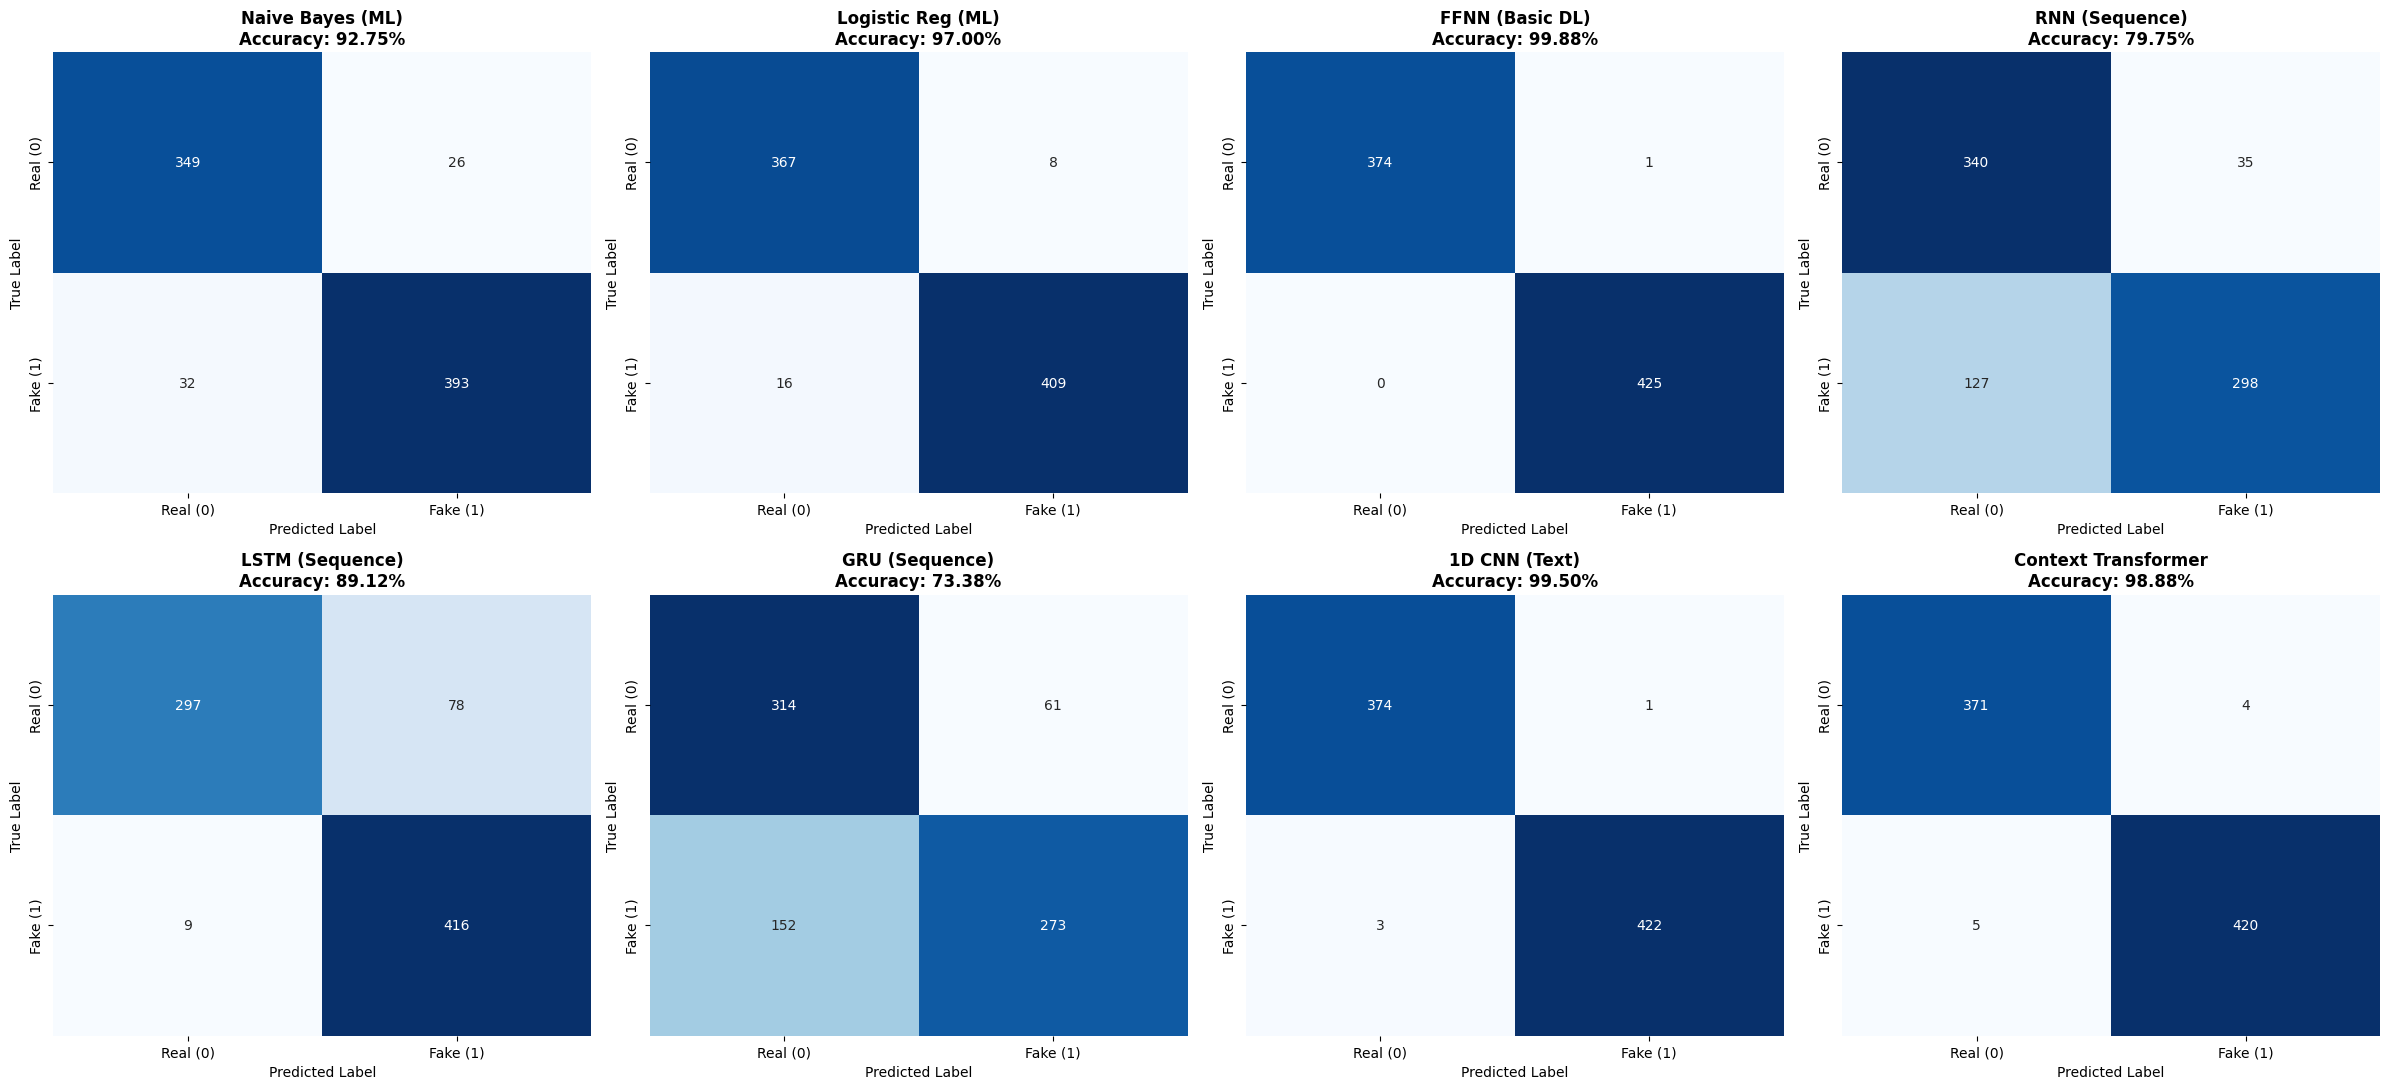

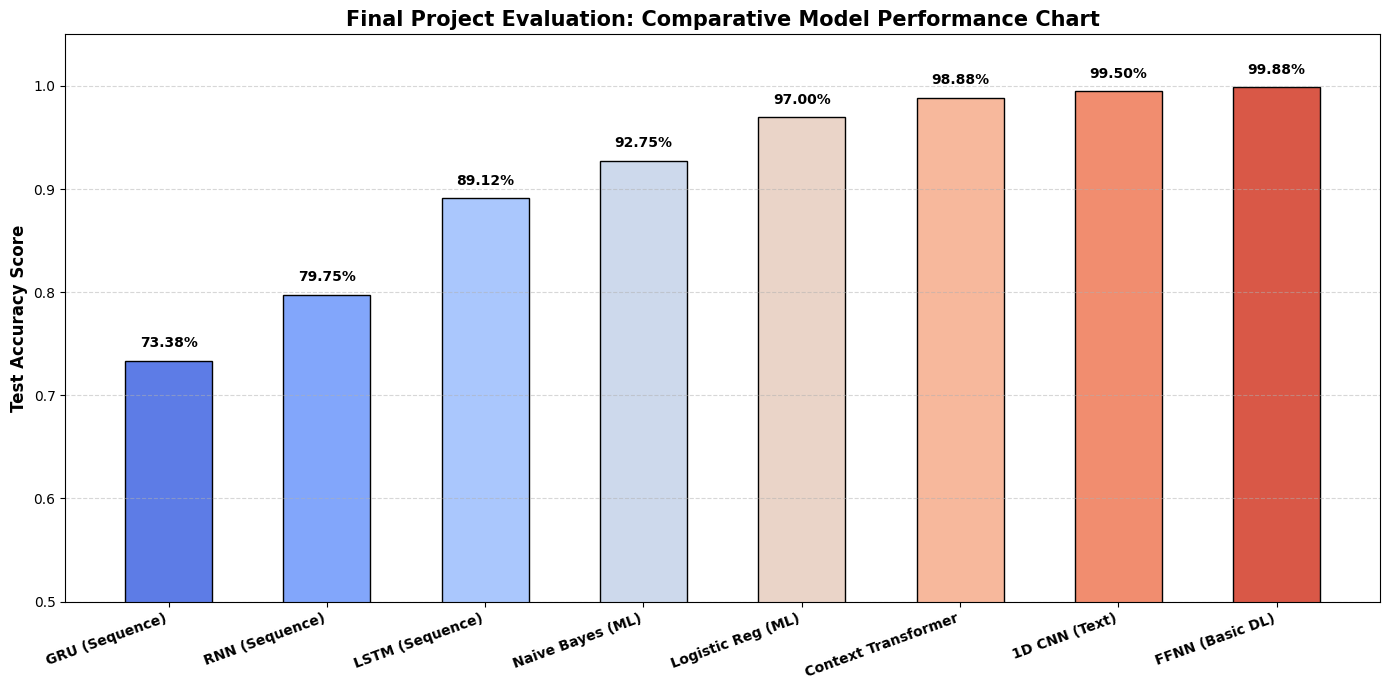

In [51]:
## Comparison of all ML and DL models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Aggregate all sequential runs cleanly
all_final_predictions = {
    "Naive Bayes (ML)": nb_preds,
    "Logistic Reg (ML)": lr_preds,
    **dl_predictions,
    "Context Transformer": transformer_preds
}
final_accuracies = {name: accuracy_score(y_test, preds) for name, preds in all_final_predictions.items()}
# Rendering all confusion matrices side-by-side
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.ravel()
for idx, (name, preds) in enumerate(all_final_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False, xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[idx].set_title(f"{name}\nAccuracy: {final_accuracies[name]*100:.2f}%", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")
plt.tight_layout()
plt.show()

# Rendering project evaluation performance chart
sorted_metrics = sorted(final_accuracies.items(), key=lambda x: x[1])
names_sorted = [item[0] for item in sorted_metrics]
values_sorted = [item[1] for item in sorted_metrics]
plt.figure(figsize=(14, 7))
chart_colors = sns.color_palette("coolwarm", len(values_sorted))
bars = plt.bar(names_sorted, values_sorted, color=chart_colors, edgecolor='black', width=0.55)
plt.ylabel('Test Accuracy Score', fontsize=12, fontweight='bold')
plt.title('Final Project Evaluation: Comparative Model Performance Chart', fontsize=15, fontweight='bold')
plt.ylim(0.50, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20, ha='right', fontsize=10, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()